In [13]:
import os
import glob
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import pandas as pd
import numpy as np

In [27]:
astro_h5ad_file = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Yuanyuan/BG_cellbender/bg_astro/HMBA_human_Astro_21clusters_withCellBenderLayerUMAP_aibs_epoch50.h5ad"
cellbender_out_dir = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Yuanyuan/BG_cellbender/aibs/outH5"
table_s1_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DESeq2_primary_markers_with_CellBender_stats.csv"

output_table_s1_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DEGs_across_BG_astrocyte_clusters_with_cluster_QC_metrics.xlsx"
output_cluster_summary_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_cluster_QC_metrics_summary.csv"
output_h5ad_with_latents = "/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Yuanyuan/BG_cellbender/bg_astro/HMBA_human_Astro_21clusters_withCellBenderLayerUMAP_aibs_epoch50_with_CB_latents.h5ad"


In [7]:
doublet_score_threshold = 0.35

# Candidate column names in astro_cb.obs for fine cluster annotation
cluster_col_candidates = [
    "Cluster",
]

# Candidate column names in Table S1 for fine cluster
table_cluster_col_candidates = [
    "Cluster",
]

In [8]:
def decode_h5_strings(x):
    """Decode h5 byte strings to regular Python strings."""
    return np.array([
        item.decode("utf-8") if isinstance(item, bytes) else str(item)
        for item in x
    ])


def normalize_cluster_name(x):
    """
    Convert cluster labels to Human-x style for merging.
    Examples:
        h-146 -> Human-146
        Human-146 -> Human-146
        146 -> Human-146
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s.startswith("Human-"):
        return s

    if s.startswith("h-"):
        return s.replace("h-", "Human-", 1)

    if s.isdigit():
        return f"Human-{s}"

    return s


def find_cluster_column(df_or_obs, candidates):
    """Find a likely cluster column."""
    cols = list(df_or_obs.columns)

    for c in candidates:
        if c in cols:
            return c

    # fallback: search for a column with h- or Human-like values
    for c in cols:
        vals = pd.Series(df_or_obs[c]).dropna().astype(str).head(100)
        if vals.str.contains(r"^(h-|Human-)\d+", regex=True).any():
            return c

    raise ValueError(
        "Could not find a cluster column. Available columns are:\n"
        + "\n".join(cols)
    )


def find_doublet_score_column(obs):
    """Find doublet score column in astro_cb.obs."""
    candidates = [
        "doublet_score",
        "Doublet_score",
        "doublet_scores",
        "DoubletFinder_score",
        "doubletFinder_score",
        "DF.classifications.score",
    ]

    for c in candidates:
        if c in obs.columns:
            return c

    # fallback: any column containing both doublet and score
    for c in obs.columns:
        lc = c.lower()
        if "doublet" in lc and "score" in lc:
            return c

    raise ValueError(
        "Could not find doublet score column in astro_cb.obs. "
        "Please check astro_cb.obs.columns."
    )


In [9]:
# ============================================================
# Step 1. Read astro_cb
# ============================================================

astro_cb = sc.read_h5ad(astro_h5ad_file)

print(astro_cb)
print("n cells:", astro_cb.n_obs)
print("n genes:", astro_cb.n_vars)

cluster_col = find_cluster_column(astro_cb.obs, cluster_col_candidates)
doublet_col = find_doublet_score_column(astro_cb.obs)

print("Using cluster column:", cluster_col)
print("Using doublet score column:", doublet_col)

astro_cb.obs["Cluster_for_TableS1"] = astro_cb.obs[cluster_col].map(normalize_cluster_name)

print(astro_cb.obs["Cluster_for_TableS1"].value_counts().head())


AnnData object with n_obs × n_vars = 136684 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac

NameError: name 'pd' is not defined

In [10]:
import pandas as pd

astro_cb.obs["Cluster_for_TableS1"] = astro_cb.obs[cluster_col].map(normalize_cluster_name)

print(astro_cb.obs["Cluster_for_TableS1"].value_counts().head())


Cluster_for_TableS1
Human-14     58596
Human-160    17037
Human-485    12908
Human-472    12864
Human-159    12053
Name: count, dtype: int64


In [14]:
# ============================================================
# Step 2. Add CellBender droplet latent variables if not already present
# ============================================================

need_extract_cellbender_latents = "cellbender_background_fraction" not in astro_cb.obs.columns

if need_extract_cellbender_latents:
    print("cellbender_background_fraction not found in astro_cb.obs.")
    print("Extracting CellBender droplet latents from .out.h5 files...")

    files = sorted(glob.glob(os.path.join(cellbender_out_dir, "*.out.h5")))
    print("Number of CellBender h5 files:", len(files))

    latent_keys = [
        "background_fraction",
        "cell_probability",
        "cell_size",
        "droplet_efficiency",
    ]

    obs_meta_list = []

    for f in files:
        lib = os.path.basename(f).replace(".out.h5", "")

        with h5py.File(f, "r") as h5:
            barcodes = decode_h5_strings(h5["matrix/barcodes"][:])
            latent_idx = h5["droplet_latents/barcode_indices_for_latents"][:]

            meta = pd.DataFrame(index=barcodes)
            meta["library"] = lib

            for key in latent_keys:
                if key in h5["droplet_latents"]:
                    vals = h5[f"droplet_latents/{key}"][:]

                    # Important:
                    # droplet_latents values correspond to barcode_indices_for_latents,
                    # not necessarily all matrix/barcodes.
                    full_vals = np.full(len(barcodes), np.nan, dtype=float)
                    full_vals[latent_idx] = vals

                    meta[f"cellbender_{key}"] = full_vals
                else:
                    print(f"{lib}: droplet_latents/{key} not found")

        # Match your existing cell naming convention: barcode-library
        meta.index = [f"{bc}-{lib}" for bc in meta.index]

        # Convert AAAC...-1-LIB to AAAC...-LIB if your astro object uses that style
        meta.index = pd.Index(meta.index).str.replace("-1-", "-", regex=False)

        obs_meta_list.append(meta)

    cb_meta = pd.concat(obs_meta_list, axis=0)

    print("CellBender metadata shape:", cb_meta.shape)
    print(cb_meta.head())

    overlap = astro_cb.obs_names.intersection(cb_meta.index)

    print("astro_cb cells:", astro_cb.n_obs)
    print("CellBender metadata cells:", cb_meta.shape[0])
    print("overlap:", len(overlap))
    print("fraction covered:", len(overlap) / astro_cb.n_obs)

    if len(overlap) != astro_cb.n_obs:
        print("\nWARNING: Not all astro_cb cells matched CellBender metadata.")
        print("Example astro_cb obs_names:")
        print(astro_cb.obs_names[:5].tolist())
        print("Example cb_meta index:")
        print(cb_meta.index[:5].tolist())

    for col in cb_meta.columns:
        astro_cb.obs[col] = cb_meta.reindex(astro_cb.obs_names)[col].values

else:
    print("cellbender_background_fraction already found in astro_cb.obs. Skipping h5 extraction.")


cellbender_background_fraction not found in astro_cb.obs.
Extracting CellBender droplet latents from .out.h5 files...
Number of CellBender h5 files: 204
CellBender metadata shape: (148248272, 5)
                            library  cellbender_background_fraction  \
AAACAGCCAAACAACA-1001_A06  1001_A06                             NaN   
AAACAGCCAAACATAG-1001_A06  1001_A06                             NaN   
AAACAGCCAAACCCTA-1001_A06  1001_A06                             NaN   
AAACAGCCAAACCTAT-1001_A06  1001_A06                             NaN   
AAACAGCCAAACCTTG-1001_A06  1001_A06                             NaN   

                           cellbender_cell_probability  cellbender_cell_size  \
AAACAGCCAAACAACA-1001_A06                          NaN                   NaN   
AAACAGCCAAACATAG-1001_A06                          NaN                   NaN   
AAACAGCCAAACCCTA-1001_A06                          NaN                   NaN   
AAACAGCCAAACCTAT-1001_A06                          NaN    

In [15]:
# ============================================================
# Step 3. Sanity check CellBender and doublet columns
# ============================================================

qc_cols_to_check = [
    "cellbender_background_fraction",
    "cellbender_cell_probability",
    "cellbender_cell_size",
    "cellbender_droplet_efficiency",
    doublet_col,
]

existing_qc_cols = [c for c in qc_cols_to_check if c in astro_cb.obs.columns]

print("\nQC columns summary:")
print(astro_cb.obs[existing_qc_cols].describe())

print("\nMissing values:")
print(astro_cb.obs[existing_qc_cols].isna().sum())




QC columns summary:
       cellbender_background_fraction  cellbender_cell_probability  \
count                   136684.000000                136684.000000   
mean                         0.054015                     0.999387   
std                          0.082215                     0.020381   
min                          0.000000                     0.001038   
25%                          0.008794                     0.999955   
50%                          0.021463                     0.999981   
75%                          0.058800                     1.000000   
max                          0.862786                     1.000000   

       cellbender_cell_size  cellbender_droplet_efficiency  doublet_score  
count         136684.000000                  136684.000000  136684.000000  
mean           28594.963719                       1.099797       0.035565  
std            11496.003283                       0.412882       0.052453  
min             2383.442139                 

In [16]:
# ============================================================
# Step 4. Cluster-level QC summary
# ============================================================

total_astro_cells = astro_cb.n_obs

cluster_qc_summary = (
    astro_cb.obs
    .groupby("Cluster_for_TableS1", observed=True)
    .agg(
        cluster_n_cells=("Cluster_for_TableS1", "size"),
        n_cells_with_CellBender_metric=("cellbender_background_fraction", lambda x: x.notna().sum()),

        mean_CellBender_background_fraction=("cellbender_background_fraction", "mean"),
        median_CellBender_background_fraction=("cellbender_background_fraction", "median"),

        mean_CellBender_cell_probability=("cellbender_cell_probability", "mean"),
        median_CellBender_cell_probability=("cellbender_cell_probability", "median"),

        mean_doublet_score=(doublet_col, "mean"),
        median_doublet_score=(doublet_col, "median"),
        max_doublet_score=(doublet_col, "max"),
        fraction_cells_doublet_score_gt_0p30=(doublet_col, lambda x: np.mean(pd.to_numeric(x, errors="coerce") > doublet_score_threshold)),
    )
    .reset_index()
    .rename(columns={"Cluster_for_TableS1": "Cluster"})
)

cluster_qc_summary["cluster_fraction_of_astrocytes"] = (
    cluster_qc_summary["cluster_n_cells"] / total_astro_cells
)

# Optional readable percent column
cluster_qc_summary["cluster_percent_of_astrocytes"] = (
    100 * cluster_qc_summary["cluster_fraction_of_astrocytes"]
)

# Round for readability in Table S1
round_cols = [
    "cluster_fraction_of_astrocytes",
    "cluster_percent_of_astrocytes",
    "mean_CellBender_background_fraction",
    "median_CellBender_background_fraction",
    "mean_CellBender_cell_probability",
    "median_CellBender_cell_probability",
    "mean_doublet_score",
    "median_doublet_score",
    "max_doublet_score",
    "fraction_cells_doublet_score_gt_0p30",
]

for c in round_cols:
    if c in cluster_qc_summary.columns:
        cluster_qc_summary[c] = cluster_qc_summary[c].astype(float).round(5)

cluster_qc_summary = cluster_qc_summary.sort_values("Cluster")

print("\nCluster QC summary:")
print(cluster_qc_summary)

cluster_qc_summary.to_csv(output_cluster_summary_file, index=False)
print("Saved cluster QC summary to:")
print(output_cluster_summary_file)



Cluster QC summary:
      Cluster  cluster_n_cells  n_cells_with_CellBender_metric  \
0     Human-7             1893                            1893   
1    Human-14            58596                           58596   
2    Human-28             1492                            1492   
3    Human-31             3350                            3350   
4   Human-143               91                              91   
5   Human-145             1783                            1783   
6   Human-146              172                             172   
7   Human-149             2649                            2649   
8   Human-150             1359                            1359   
9   Human-152             1322                            1322   
10  Human-159            12053                           12053   
11  Human-160            17037                           17037   
12  Human-227              162                             162   
13  Human-230               78                         

In [25]:
# ============================================================
# Step 5. Add cluster-level QC metrics to every relevant Table S1 sheet
# ============================================================

# ============================================================
# Step 5. Add cluster-level QC metrics to Table S1 CSV
# ============================================================

df = pd.read_csv(table_s1_file)

metric_cols = [
    "cluster_n_cells",
    "cluster_fraction_of_astrocytes",
    "cluster_percent_of_astrocytes",
    "n_cells_with_CellBender_metric",
    "mean_CellBender_background_fraction",
    "median_CellBender_background_fraction",
    "mean_CellBender_cell_probability",
    "median_CellBender_cell_probability",
    "mean_doublet_score",
    "median_doublet_score",
    "max_doublet_score",
    "fraction_cells_doublet_score_gt_0p30",
]

print("\nProcessing CSV Table S1")
print("Shape before:", df.shape)

table_cluster_col = find_cluster_column(df, table_cluster_col_candidates)
print("Using Table S1 cluster column:", table_cluster_col)

df = df.copy()
df["Cluster_for_merge"] = df[table_cluster_col].map(normalize_cluster_name)

# Remove old versions of these columns if rerunning
cols_to_drop = [c for c in metric_cols if c in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

df = df.merge(
    cluster_qc_summary[["Cluster"] + metric_cols],
    left_on="Cluster_for_merge",
    right_on="Cluster",
    how="left"
)

df = df.drop(columns=["Cluster_for_merge"])

# Clean possible duplicate Cluster columns
if "Cluster_y" in df.columns:
    df = df.drop(columns=["Cluster_y"])
if "Cluster_x" in df.columns:
    df = df.rename(columns={"Cluster_x": "Cluster"})

missing_metric_rows = df["cluster_n_cells"].isna().sum()
print("Rows without matched cluster metrics:", missing_metric_rows)

print("Shape after:", df.shape)

# Save
df.to_csv(output_table_s1_file, index=False)


Processing CSV Table S1
Shape before: (10176, 23)
Using Table S1 cluster column: cluster
Rows without matched cluster metrics: 0
Shape after: (10176, 36)


/scratch/fast/19714149/ipykernel_2626163/2536640111.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if vals.str.contains(r"^(h-|Human-)\d+", regex=True).any():
/scratch/fast/19714149/ipykernel_2626163/2536640111.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if vals.str.contains(r"^(h-|Human-)\d+", regex=True).any():
/scratch/fast/19714149/ipykernel_2626163/2536640111.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if vals.str.contains(r"^(h-|Human-)\d+", regex=True).any():
/scratch/fast/19714149/ipykernel_2626163/2536640111.py:45: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if vals.str.contains(r"^(h-|Human-)\d+", reg

In [28]:
# ============================================================
# Step 6. Prepare output sheets
# ============================================================

# Main updated Table S1 sheet: original CSV + added QC metric columns
updated_sheets = {
    "Table_S1_with_QC": df,
    "Cluster_QC_metrics_summary": cluster_qc_summary,
}


# ============================================================
# Step 7. Write updated Table S1 as a two-sheet Excel file
# ============================================================

# Make sure this output file ends with .xlsx
# Example:
# output_table_s1_file = "/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_with_cluster_QC_metrics.xlsx"

with pd.ExcelWriter(output_table_s1_file, engine="openpyxl") as writer:
    updated_sheets["Table_S1_with_QC"].to_excel(
        writer,
        sheet_name="Table_S1_with_QC",
        index=False
    )

    updated_sheets["Cluster_QC_metrics_summary"].to_excel(
        writer,
        sheet_name="Cluster_QC_metrics_summary",
        index=False
    )

print("\nSaved updated Table S1 to:")
print(output_table_s1_file)


Saved updated Table S1 to:
/home/yuanyuan.fu/hMBA_hu_all/scripts_for_study_paper/real_figures/Table_S1_DEGs_across_BG_astrocyte_clusters_with_cluster_QC_metrics.xlsx


In [29]:
astro_cb

AnnData object with n_obs × n_vars = 136684 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'cluster_id', 'cell_type_ontology_term', 'load_id', 'donor_id', 'assay', 'assay_ontology_term_id', 'organism', 'organism_ontology_term_id', 'development_stage', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'brain_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac

[<Axes: title={'center': 'cluster'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>,
 <Axes: title={'center': 'AQP4'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>,
 <Axes: title={'center': 'TNC'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>,
 <Axes: title={'center': 'cellbender_background_fraction'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>,
 <Axes: title={'center': 'cellbender_cell_probability'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>,
 <Axes: title={'center': 'cellbender_cell_size'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>,
 <Axes: title={'center': 'cellbender_droplet_efficiency'}, xlabel='X_umap_beforeCB1', ylabel='X_umap_beforeCB2'>]

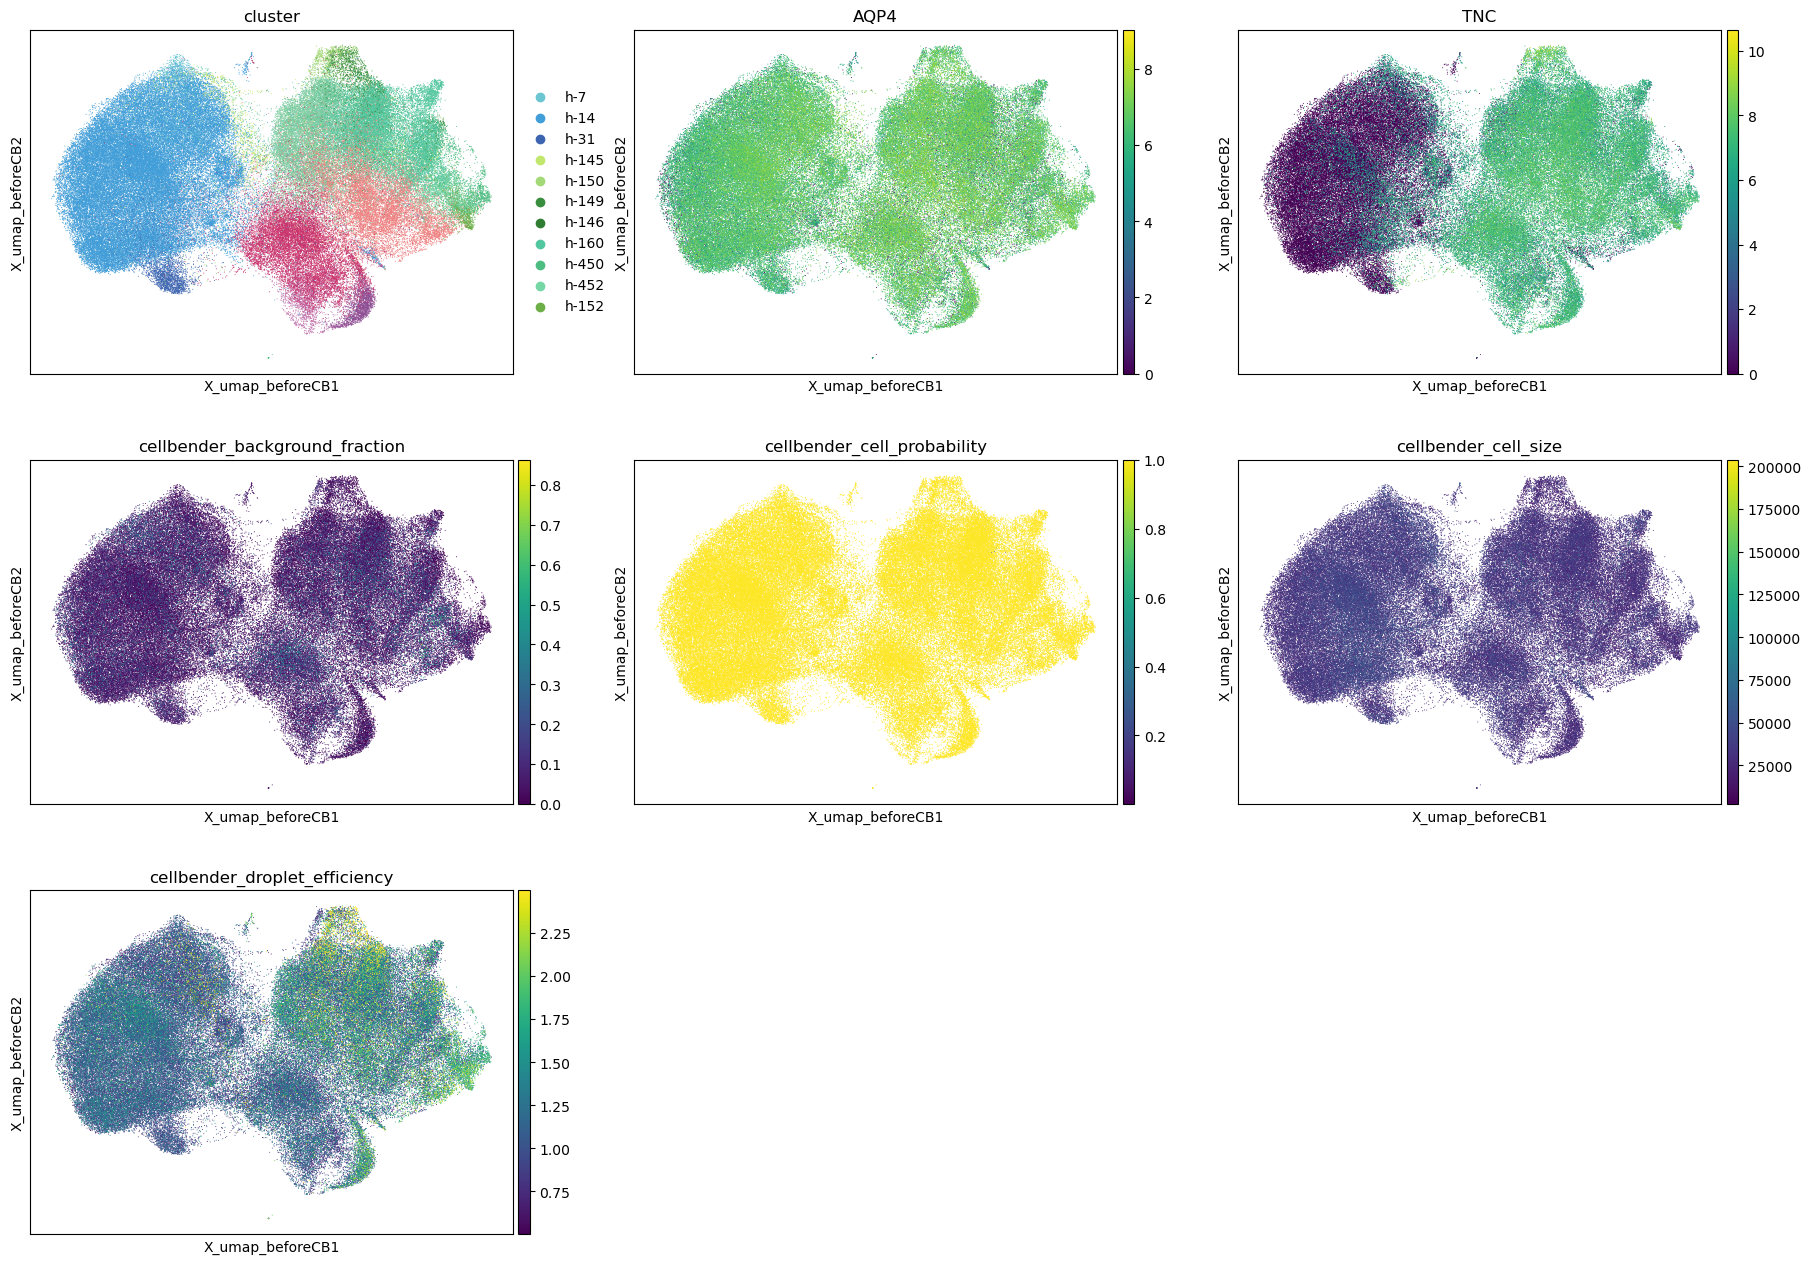

In [30]:
sc.pl.embedding(
    astro_cb,
    layer = "before_cellbender_normX",
    basis="X_umap_beforeCB", #"X_UMAP",
    #color_map="bwr",
    color= ["cluster", "AQP4", "TNC", "cellbender_background_fraction",'cellbender_cell_probability', 'cellbender_cell_size', 'cellbender_droplet_efficiency'],
    show=False,
    ncols=3,
    use_raw=False,
    size=2,
)





In [31]:
# ============================================================
# Step 8. Save astro_cb with CellBender latent obs columns
# ============================================================

astro_cb.write_h5ad(output_h5ad_with_latents)

print("\nSaved astro_cb with CellBender latent metrics to:")
print(output_h5ad_with_latents)


Saved astro_cb with CellBender latent metrics to:
/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Yuanyuan/BG_cellbender/bg_astro/HMBA_human_Astro_21clusters_withCellBenderLayerUMAP_aibs_epoch50_with_CB_latents.h5ad


In [4]:
with h5py.File(test_h5, "r") as h5:
    print("droplet_latents keys:")
    for k in h5["droplet_latents"].keys():
        print(k)

    print("\nglobal_latents keys:")
    for k in h5["global_latents"].keys():
        print(k)

droplet_latents keys:
background_fraction
barcode_indices_for_latents
cell_probability
cell_size
droplet_efficiency
gene_expression_encoding

global_latents keys:
ambient_expression
cell_size_lognormal_std
empty_droplet_size_lognormal_loc
empty_droplet_size_lognormal_scale
swapping_fraction_dist_params
